# F1 Cornering Classification

This notebook contains only the active modelling pipeline:

1. Load the existing manifests and fixed session split.
2. Train or load the CNN.
3. Train the delta-only logistic regression.
4. Generate lap-level CNN probabilities.
5. Compare CNN aggregation methods.
6. Fuse CNN and delta probabilities on the validation set.

The test set remains untouched during model development.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## 1. Configuration


In [2]:
batch_size = 16
num_epochs = 20
learning_rate = 1e-4
seed = 42

# Set to True only when you deliberately want to retrain and overwrite
# the saved best_resnet18.pth checkpoint.
TRAIN_CNN = True #False

np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


## 2. Project paths and saved manifests


In [3]:
possible_project_roots = [
    Path.cwd(),
    Path.cwd().parent,
]

project_root = next(
    (
        path.resolve()
        for path in possible_project_roots
        if (
            path
            / "Data"
            / "manifests"
            / "image-manifest-with-split.csv"
        ).exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the project root containing "
        "Data/manifests/image-manifest-with-split.csv.\n"
        f"Current working directory: {Path.cwd()}"
    )

data_root = project_root / "Data"
manifest_dir = data_root / "manifests"

image_manifest_path = manifest_dir / "image-manifest.csv"
lap_manifest_path = manifest_dir / "lap-manifest.csv"

split_image_manifest_path = (
    manifest_dir / "image-manifest-with-split.csv"
)

split_lap_manifest_path = (
    manifest_dir / "lap-manifest-with-split.csv"
)

code_directory = project_root / "Code"
best_model_path = (
    code_directory / "best_resnet18.pth"
    if code_directory.exists()
    else Path.cwd() / "best_resnet18.pth"
)

print("Project root:", project_root)
print("Manifest directory:", manifest_dir)
print("CNN checkpoint:", best_model_path)


Project root: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project
Manifest directory: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests
CNN checkpoint: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18.pth


In [4]:
image_manifest = pd.read_csv(image_manifest_path)
lap_manifest = pd.read_csv(lap_manifest_path)

image_manifest_with_split = pd.read_csv(
    split_image_manifest_path
)

lap_manifest_with_split = pd.read_csv(
    split_lap_manifest_path
)

valid_splits = {"train", "validation", "test"}

assert len(image_manifest) == 488
assert len(lap_manifest) == 122
assert len(image_manifest_with_split) == 488
assert len(lap_manifest_with_split) == 122

assert set(
    image_manifest_with_split["split"].unique()
) == valid_splits

assert set(
    lap_manifest_with_split["split"].unique()
) == valid_splits

assert lap_manifest_with_split[
    "global_lap_num"
].is_unique

assert (
    image_manifest_with_split
    .groupby("global_lap_num")
    .size()
    .eq(4)
    .all()
)

print("Saved manifests loaded and validated.")


Saved manifests loaded and validated.


## 3. Fixed train, validation and test subsets


In [5]:
train_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

train_lap_df = (
    lap_manifest_with_split[
        lap_manifest_with_split["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_lap_df = (
    lap_manifest_with_split[
        lap_manifest_with_split["split"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_lap_df = (
    lap_manifest_with_split[
        lap_manifest_with_split["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(train_image_df) == 340
assert len(validation_image_df) == 72
assert len(test_image_df) == 76

assert len(train_lap_df) == 85
assert len(validation_lap_df) == 18
assert len(test_lap_df) == 19

print("Training images:", len(train_image_df))
print("Validation images:", len(validation_image_df))
print("Reserved test images:", len(test_image_df))


Training images: 340
Validation images: 72
Reserved test images: 76


## 4. Image transforms, datasets and data loaders


In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

weights = ResNet18_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])


class ManifestImageDataset(Dataset):
    def __init__(
        self,
        manifest_df,
        project_root,
        transform=None,
    ):
        self.manifest_df = (
            manifest_df.copy().reset_index(drop=True)
        )
        self.project_root = Path(project_root).resolve()
        self.transform = transform

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, index):
        row = self.manifest_df.iloc[index]

        image_path = Path(
            row["cnn_repo_relative_path"]
        )

        if not image_path.is_absolute():
            image_path = self.project_root / image_path

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image was not found:\n{image_path}"
            )

        with Image.open(image_path) as image:
            image = image.convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

        label = int(row["class_index"])

        return image, label


Using device: cuda


In [7]:
train_dataset = ManifestImageDataset(
    train_image_df,
    project_root,
    train_transform,
)

validation_dataset = ManifestImageDataset(
    validation_image_df,
    project_root,
    eval_transform,
)

test_dataset = ManifestImageDataset(
    test_image_df,
    project_root,
    eval_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Reserved test batches:", len(test_loader))


Train batches: 22
Validation batches: 5
Reserved test batches: 5


## 5. CNN definition and training


In [8]:
class_names = [
    "optimal_laps",
    "standard_laps",
    "sub_standard_laps",
]

num_classes = len(class_names)

model = models.resnet18(weights=weights)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes,
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
)


In [9]:
def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(
        optimizer is not None
    ):
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            if optimizer is not None:
                optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if optimizer is not None:
                loss.backward()
                optimizer.step()

            running_loss += (
                loss.item() * inputs.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )


In [10]:
if TRAIN_CNN:
    best_val_acc = -np.inf

    for epoch in range(num_epochs):
        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        val_loss, val_acc = run_epoch(
            model,
            val_loader,
            criterion,
        )

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc

            torch.save(
                model.state_dict(),
                best_model_path,
            )

    print(
        "Best validation accuracy:",
        best_val_acc,
    )

if not best_model_path.exists():
    raise FileNotFoundError(
        "The CNN checkpoint does not exist:\n"
        f"{best_model_path}\n"
        "Set TRAIN_CNN = True and run this cell "
        "to train a new checkpoint."
    )

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device,
        weights_only=True,
    )
)

model = model.to(device)
model.eval()

print(
    "Loaded best CNN checkpoint:",
    best_model_path,
)


Epoch 1/20 | Train Loss: 1.1082 | Train Acc: 0.4324 | Val Loss: 1.2318 | Val Acc: 0.3472
Epoch 2/20 | Train Loss: 0.7264 | Train Acc: 0.6735 | Val Loss: 1.3229 | Val Acc: 0.4306
Epoch 3/20 | Train Loss: 0.4244 | Train Acc: 0.8794 | Val Loss: 1.4154 | Val Acc: 0.4306
Epoch 4/20 | Train Loss: 0.2747 | Train Acc: 0.9235 | Val Loss: 1.7789 | Val Acc: 0.4861
Epoch 5/20 | Train Loss: 0.2057 | Train Acc: 0.9324 | Val Loss: 1.7304 | Val Acc: 0.4583
Epoch 6/20 | Train Loss: 0.0944 | Train Acc: 0.9882 | Val Loss: 1.8863 | Val Acc: 0.4444
Epoch 7/20 | Train Loss: 0.0460 | Train Acc: 0.9971 | Val Loss: 1.9517 | Val Acc: 0.3750
Epoch 8/20 | Train Loss: 0.0388 | Train Acc: 0.9971 | Val Loss: 1.9521 | Val Acc: 0.4167
Epoch 9/20 | Train Loss: 0.0272 | Train Acc: 0.9971 | Val Loss: 1.9024 | Val Acc: 0.4306
Epoch 10/20 | Train Loss: 0.0190 | Train Acc: 1.0000 | Val Loss: 2.2440 | Val Acc: 0.4722
Epoch 11/20 | Train Loss: 0.0142 | Train Acc: 1.0000 | Val Loss: 1.9968 | Val Acc: 0.4722
Epoch 12/20 | Train

The test loader is intentionally not evaluated here. The fixed test set remains reserved until the CNN, delta model and fusion method have been selected.


## 6. Delta-only logistic regression


In [11]:
delta_feature_columns = [
    "delta_1_seconds",
    "delta_2_seconds",
]

delta_available_mask = (
    lap_manifest_with_split[
        "delta_1_seconds"
    ].notna()
    & lap_manifest_with_split[
        "delta_2_seconds"
    ].notna()
)

delta_laps = (
    lap_manifest_with_split[
        delta_available_mask
    ]
    .copy()
    .reset_index(drop=True)
)

delta_train_df = (
    delta_laps[
        delta_laps["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

delta_validation_df = (
    delta_laps[
        delta_laps["split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

delta_test_df = (
    delta_laps[
        delta_laps["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

X_delta_train = delta_train_df[
    delta_feature_columns
].to_numpy()

y_delta_train = delta_train_df[
    "class_index"
].to_numpy()

X_delta_validation = delta_validation_df[
    delta_feature_columns
].to_numpy()

y_delta_validation = delta_validation_df[
    "class_index"
].to_numpy()

print("Delta training laps:", len(delta_train_df))
print(
    "Delta validation laps:",
    len(delta_validation_df),
)
print(
    "Delta test laps reserved:",
    len(delta_test_df),
)


Delta training laps: 64
Delta validation laps: 18
Delta test laps reserved: 12


In [12]:
training_class_counts = (
    delta_train_df["class_index"]
    .value_counts()
)

majority_class_index = int(
    training_class_counts.idxmax()
)

majority_validation_predictions = np.full(
    len(y_delta_validation),
    majority_class_index,
)

majority_validation_accuracy = accuracy_score(
    y_delta_validation,
    majority_validation_predictions,
)

majority_validation_balanced_accuracy = (
    balanced_accuracy_score(
        y_delta_validation,
        majority_validation_predictions,
    )
)

delta_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
        ),
    ),
])

delta_model.fit(
    X_delta_train,
    y_delta_train,
)

delta_validation_predictions = (
    delta_model.predict(
        X_delta_validation
    )
)

delta_validation_probabilities = (
    delta_model.predict_proba(
        X_delta_validation
    )
)

delta_validation_accuracy = accuracy_score(
    y_delta_validation,
    delta_validation_predictions,
)

delta_validation_balanced_accuracy = (
    balanced_accuracy_score(
        y_delta_validation,
        delta_validation_predictions,
    )
)

print(
    "Majority baseline accuracy:",
    f"{majority_validation_accuracy:.4f}",
)

print(
    "Majority baseline balanced accuracy:",
    f"{majority_validation_balanced_accuracy:.4f}",
)

print(
    "Delta validation accuracy:",
    f"{delta_validation_accuracy:.4f}",
)

print(
    "Delta validation balanced accuracy:",
    f"{delta_validation_balanced_accuracy:.4f}",
)


Majority baseline accuracy: 0.5000
Majority baseline balanced accuracy: 0.3333
Delta validation accuracy: 0.8333
Delta validation balanced accuracy: 0.7963


                   precision    recall  f1-score   support

     optimal_laps     0.6667    0.5000    0.5714         4
    standard_laps     0.8889    0.8889    0.8889         9
sub_standard_laps     0.8333    1.0000    0.9091         5

         accuracy                         0.8333        18
        macro avg     0.7963    0.7963    0.7898        18
     weighted avg     0.8241    0.8333    0.8240        18



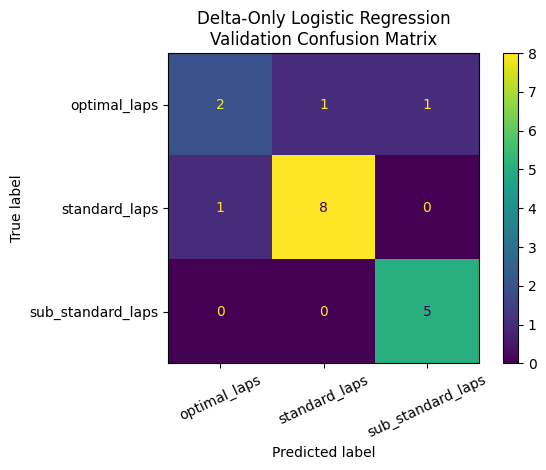

In [13]:
print(
    classification_report(
        y_delta_validation,
        delta_validation_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_delta_validation,
    delta_validation_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Delta-Only Logistic Regression\n"
    "Validation Confusion Matrix"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [14]:
delta_model_class_order = (
    delta_model.named_steps[
        "classifier"
    ].classes_
)

assert np.array_equal(
    delta_model_class_order,
    np.arange(num_classes),
)

delta_validation_probability_df = pd.DataFrame({
    "global_lap_num":
        delta_validation_df[
            "global_lap_num"
        ].to_numpy(),

    "true_class_index":
        y_delta_validation,

    "delta_predicted_class_index":
        delta_validation_predictions,

    "delta_probability_optimal":
        delta_validation_probabilities[:, 0],

    "delta_probability_standard":
        delta_validation_probabilities[:, 1],

    "delta_probability_sub_standard":
        delta_validation_probabilities[:, 2],
})

delta_validation_probability_path = (
    manifest_dir
    / "delta-validation-probabilities.csv"
)

delta_validation_probability_df.to_csv(
    delta_validation_probability_path,
    index=False,
)

display(
    delta_validation_probability_df.head()
)

print(
    "Saved delta validation probabilities:",
    delta_validation_probability_path,
)


,global_lap_num,true_class_index,delta_predicted_class_index,delta_probability_optimal,delta_probability_standard,delta_probability_sub_standard
0,60,0,0,0.489005,0.428463,0.082533
1,61,2,2,0.006812,0.225475,0.767714
2,62,1,1,0.139268,0.496220,0.364512
3,63,1,1,0.411254,0.483273,0.105473
4,65,2,2,0.000116,0.044943,0.954941


Saved delta validation probabilities: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\delta-validation-probabilities.csv


## 7. CNN validation outputs and lap-level aggregation


In [15]:
validation_logits_batches = []
validation_probability_batches = []
validation_prediction_batches = []
validation_label_batches = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        predictions = logits.argmax(dim=1)

        validation_logits_batches.append(
            logits.cpu().numpy()
        )

        validation_probability_batches.append(
            probabilities.cpu().numpy()
        )

        validation_prediction_batches.append(
            predictions.cpu().numpy()
        )

        validation_label_batches.append(
            labels.numpy()
        )

validation_image_logits = np.concatenate(
    validation_logits_batches,
    axis=0,
)

validation_image_probabilities = np.concatenate(
    validation_probability_batches,
    axis=0,
)

validation_image_predictions = np.concatenate(
    validation_prediction_batches,
    axis=0,
)

validation_image_labels = np.concatenate(
    validation_label_batches,
    axis=0,
)

assert validation_image_logits.shape == (72, 3)

assert np.array_equal(
    validation_image_df[
        "class_index"
    ].to_numpy(),
    validation_image_labels,
)

print(
    "Validation logits shape:",
    validation_image_logits.shape,
)

print(
    "Validation probabilities shape:",
    validation_image_probabilities.shape,
)


Validation logits shape: (72, 3)
Validation probabilities shape: (72, 3)


In [16]:
cnn_aggregation_image_df = (
    validation_image_df.copy()
)

for class_index, class_label in enumerate([
    "optimal",
    "standard",
    "sub_standard",
]):
    cnn_aggregation_image_df[
        f"logit_{class_label}"
    ] = validation_image_logits[
        :,
        class_index,
    ]

    cnn_aggregation_image_df[
        f"probability_{class_label}"
    ] = validation_image_probabilities[
        :,
        class_index,
    ]

cnn_aggregation_image_df[
    "image_predicted_class_index"
] = validation_image_predictions

cnn_aggregation_image_df[
    "image_predicted_class_name"
] = [
    class_names[class_index]
    for class_index
    in validation_image_predictions
]

display(
    cnn_aggregation_image_df[[
        "global_lap_num",
        "signal_type",
        "hit_number",
        "class_name",
        "image_predicted_class_name",
        "probability_optimal",
        "probability_standard",
        "probability_sub_standard",
    ]].head(12)
)


,global_lap_num,signal_type,hit_number,class_name,image_predicted_class_name,probability_optimal,probability_standard,probability_sub_standard
0,60,brake,1,optimal_laps,standard_laps,0.232110,0.665560,0.102331
1,60,brake,2,optimal_laps,standard_laps,0.059406,0.931964,0.008630
2,60,throttle,1,optimal_laps,standard_laps,0.095288,0.833739,0.070972
3,60,throttle,2,optimal_laps,standard_laps,0.117976,0.732989,0.149035
4,61,brake,1,sub_standard_laps,standard_laps,0.261445,0.649394,0.089161
5,61,brake,2,sub_standard_laps,optimal_laps,0.531560,0.444779,0.023661
6,61,throttle,1,sub_standard_laps,standard_laps,0.006915,0.738837,0.254248
7,61,throttle,2,sub_standard_laps,standard_laps,0.124153,0.666900,0.208946
8,62,brake,1,standard_laps,sub_standard_laps,0.088335,0.454671,0.456994
9,62,brake,2,standard_laps,standard_laps,0.151942,0.768415,0.079643


In [17]:
probability_columns = [
    "probability_optimal",
    "probability_standard",
    "probability_sub_standard",
]

logit_columns = [
    "logit_optimal",
    "logit_standard",
    "logit_sub_standard",
]


def numpy_softmax(values):
    shifted_values = (
        values
        - values.max(
            axis=1,
            keepdims=True,
        )
    )

    exponentials = np.exp(
        shifted_values
    )

    return (
        exponentials
        / exponentials.sum(
            axis=1,
            keepdims=True,
        )
    )


def majority_vote_with_probability_tiebreak(
    image_predictions,
    image_probabilities,
):
    vote_counts = np.bincount(
        image_predictions,
        minlength=num_classes,
    )

    tied_classes = np.flatnonzero(
        vote_counts == vote_counts.max()
    )

    if len(tied_classes) == 1:
        return int(tied_classes[0])

    mean_probabilities = (
        image_probabilities.mean(axis=0)
    )

    return int(
        tied_classes[
            mean_probabilities[
                tied_classes
            ].argmax()
        ]
    )


In [18]:
aggregation_records = []

for global_lap_num, lap_images in (
    cnn_aggregation_image_df
    .groupby("global_lap_num")
):
    lap_images = (
        lap_images
        .sort_values([
            "signal_type",
            "hit_number",
        ])
        .reset_index(drop=True)
    )

    if len(lap_images) != 4:
        raise ValueError(
            f"Lap {global_lap_num} has "
            f"{len(lap_images)} images."
        )

    first_row = lap_images.iloc[0]

    all_probabilities = (
        lap_images[
            probability_columns
        ].to_numpy()
    )

    all_logits = (
        lap_images[
            logit_columns
        ].to_numpy()
    )

    all_image_predictions = (
        lap_images[
            "image_predicted_class_index"
        ].to_numpy()
    )

    brake_images = lap_images[
        lap_images["signal_type"]
        == "brake"
    ]

    throttle_images = lap_images[
        lap_images["signal_type"]
        == "throttle"
    ]

    mean_softmax_probabilities = (
        all_probabilities.mean(axis=0)
    )

    mean_logit_probabilities = (
        numpy_softmax(
            all_logits.mean(
                axis=0,
                keepdims=True,
            )
        )[0]
    )

    brake_probabilities = (
        brake_images[
            probability_columns
        ].to_numpy().mean(axis=0)
    )

    throttle_probabilities = (
        throttle_images[
            probability_columns
        ].to_numpy().mean(axis=0)
    )

    aggregation_records.append({
        "global_lap_num":
            int(global_lap_num),

        "session":
            int(first_row["session"]),

        "session_lap_num":
            int(first_row["session_lap_num"]),

        "class_name":
            first_row["class_name"],

        "class_index":
            int(first_row["class_index"]),

        "mean_softmax_prediction":
            int(mean_softmax_probabilities.argmax()),

        "mean_logits_prediction":
            int(mean_logit_probabilities.argmax()),

        "majority_vote_prediction":
            majority_vote_with_probability_tiebreak(
                all_image_predictions,
                all_probabilities,
            ),

        "brake_only_prediction":
            int(brake_probabilities.argmax()),

        "throttle_only_prediction":
            int(throttle_probabilities.argmax()),

        "mean_softmax_probability_optimal":
            mean_softmax_probabilities[0],

        "mean_softmax_probability_standard":
            mean_softmax_probabilities[1],

        "mean_softmax_probability_sub_standard":
            mean_softmax_probabilities[2],

        "mean_logits_probability_optimal":
            mean_logit_probabilities[0],

        "mean_logits_probability_standard":
            mean_logit_probabilities[1],

        "mean_logits_probability_sub_standard":
            mean_logit_probabilities[2],

        "brake_probability_optimal":
            brake_probabilities[0],

        "brake_probability_standard":
            brake_probabilities[1],

        "brake_probability_sub_standard":
            brake_probabilities[2],

        "throttle_probability_optimal":
            throttle_probabilities[0],

        "throttle_probability_standard":
            throttle_probabilities[1],

        "throttle_probability_sub_standard":
            throttle_probabilities[2],
    })

cnn_aggregation_results = (
    pd.DataFrame(aggregation_records)
    .sort_values("global_lap_num")
    .reset_index(drop=True)
)

assert len(cnn_aggregation_results) == 18

display(
    cnn_aggregation_results.head()
)


,global_lap_num,session,session_lap_num,class_name,class_index,mean_softmax_prediction,mean_logits_prediction,majority_vote_prediction,brake_only_prediction,throttle_only_prediction,...,mean_softmax_probability_sub_standard,mean_logits_probability_optimal,mean_logits_probability_standard,mean_logits_probability_sub_standard,brake_probability_optimal,brake_probability_standard,brake_probability_sub_standard,throttle_probability_optimal,throttle_probability_standard,throttle_probability_sub_standard
0,60,7,4,optimal_laps,0,1,1,1,1,1,...,0.082742,0.117266,0.824634,0.058100,0.145758,0.798762,0.055480,0.106632,0.783364,0.110004
1,61,7,5,sub_standard_laps,2,1,1,1,1,1,...,0.144004,0.127206,0.747564,0.125230,0.396502,0.547086,0.056411,0.065534,0.702869,0.231597
2,62,7,6,standard_laps,1,1,1,1,1,2,...,0.384894,0.095856,0.557093,0.347051,0.120139,0.611543,0.268319,0.103330,0.395200,0.501469
3,63,7,7,standard_laps,1,1,1,1,1,1,...,0.136751,0.158049,0.770782,0.071170,0.078200,0.801788,0.120012,0.274767,0.571744,0.153489
4,65,7,9,sub_standard_laps,2,1,1,1,1,1,...,0.281188,0.123173,0.734400,0.142427,0.198640,0.655862,0.145498,0.121691,0.461431,0.416878


In [19]:
y_cnn_validation = (
    cnn_aggregation_results[
        "class_index"
    ].to_numpy()
)

aggregation_methods = {
    "Mean softmax — all four images":
        "mean_softmax_prediction",

    "Mean logits, then softmax":
        "mean_logits_prediction",

    "Majority vote":
        "majority_vote_prediction",

    "Brake images only":
        "brake_only_prediction",

    "Throttle images only":
        "throttle_only_prediction",
}

aggregation_metric_records = []

for method_name, prediction_column in (
    aggregation_methods.items()
):
    predictions = (
        cnn_aggregation_results[
            prediction_column
        ].to_numpy()
    )

    aggregation_metric_records.append({
        "aggregation_method":
            method_name,

        "accuracy":
            accuracy_score(
                y_cnn_validation,
                predictions,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_cnn_validation,
                predictions,
            ),

        "correct_laps":
            int(
                (
                    y_cnn_validation
                    == predictions
                ).sum()
            ),

        "total_laps":
            len(y_cnn_validation),
    })

cnn_aggregation_comparison = (
    pd.DataFrame(
        aggregation_metric_records
    )
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    cnn_aggregation_comparison
)


,aggregation_method,accuracy,balanced_accuracy,correct_laps,total_laps
0,Majority vote,0.555556,0.416667,10,18
1,Brake images only,0.500000,0.379630,9,18
2,Throttle images only,0.500000,0.362963,9,18
3,Mean softmax — all four images,0.500000,0.333333,9,18
4,"Mean logits, then softmax",0.500000,0.333333,9,18


Best standalone CNN aggregation: Majority vote
                   precision    recall  f1-score   support

     optimal_laps     1.0000    0.2500    0.4000         4
    standard_laps     0.5294    1.0000    0.6923         9
sub_standard_laps     0.0000    0.0000    0.0000         5

         accuracy                         0.5556        18
        macro avg     0.5098    0.4167    0.3641        18
     weighted avg     0.4869    0.5556    0.4350        18



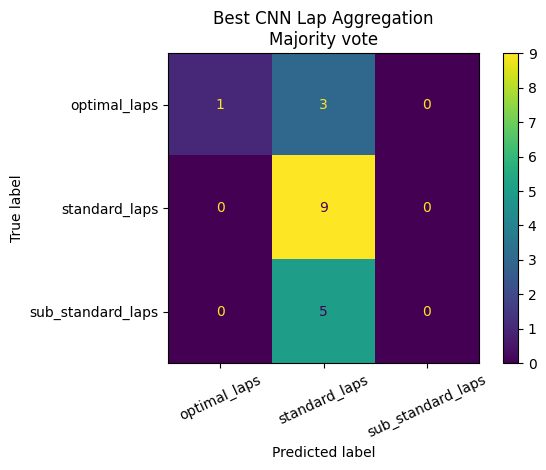

In [20]:
best_aggregation_method = (
    cnn_aggregation_comparison
    .iloc[0]["aggregation_method"]
)

best_prediction_column = (
    aggregation_methods[
        best_aggregation_method
    ]
)

best_aggregation_predictions = (
    cnn_aggregation_results[
        best_prediction_column
    ].to_numpy()
)

print(
    "Best standalone CNN aggregation:",
    best_aggregation_method,
)

print(
    classification_report(
        y_cnn_validation,
        best_aggregation_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_cnn_validation,
    best_aggregation_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Best CNN Lap Aggregation\n"
    f"{best_aggregation_method}"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [21]:
cnn_aggregation_results_path = (
    manifest_dir
    / "cnn-validation-aggregation-results.csv"
)

cnn_aggregation_comparison_path = (
    manifest_dir
    / "cnn-validation-aggregation-comparison.csv"
)

cnn_aggregation_results.to_csv(
    cnn_aggregation_results_path,
    index=False,
)

cnn_aggregation_comparison.to_csv(
    cnn_aggregation_comparison_path,
    index=False,
)

print(
    "Saved CNN aggregation results:",
    cnn_aggregation_results_path,
)


Saved CNN aggregation results: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\cnn-validation-aggregation-results.csv


## 8. CNN and delta probability fusion


In [22]:
fusion_validation_df = (
    cnn_aggregation_results
    .merge(
        delta_validation_probability_df,
        on="global_lap_num",
        how="inner",
        validate="one_to_one",
    )
)

assert len(fusion_validation_df) == 18

assert (
    fusion_validation_df[
        "class_index"
    ]
    == fusion_validation_df[
        "true_class_index"
    ]
).all()

cnn_validation_probabilities = (
    fusion_validation_df[[
        "mean_softmax_probability_optimal",
        "mean_softmax_probability_standard",
        "mean_softmax_probability_sub_standard",
    ]]
    .to_numpy()
)

delta_validation_probabilities = (
    fusion_validation_df[[
        "delta_probability_optimal",
        "delta_probability_standard",
        "delta_probability_sub_standard",
    ]]
    .to_numpy()
)

fusion_true_labels = (
    fusion_validation_df[
        "class_index"
    ].to_numpy()
)

print(
    "Validation laps available for fusion:",
    len(fusion_validation_df),
)


Validation laps available for fusion: 18


In [23]:
fusion_weight_records = []

for cnn_weight in np.linspace(
    0.0,
    1.0,
    101,
):
    delta_weight = 1.0 - cnn_weight

    combined_probabilities = (
        cnn_weight
        * cnn_validation_probabilities
        + delta_weight
        * delta_validation_probabilities
    )

    combined_predictions = (
        combined_probabilities.argmax(
            axis=1
        )
    )

    fusion_weight_records.append({
        "cnn_weight":
            cnn_weight,

        "delta_weight":
            delta_weight,

        "accuracy":
            accuracy_score(
                fusion_true_labels,
                combined_predictions,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                fusion_true_labels,
                combined_predictions,
            ),
    })

fusion_weight_results = pd.DataFrame(
    fusion_weight_records
)

best_fusion_row = (
    fusion_weight_results
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
            "cnn_weight",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)

best_cnn_weight = float(
    best_fusion_row["cnn_weight"]
)

best_delta_weight = float(
    best_fusion_row["delta_weight"]
)

best_fusion_probabilities = (
    best_cnn_weight
    * cnn_validation_probabilities
    + best_delta_weight
    * delta_validation_probabilities
)

best_fusion_predictions = (
    best_fusion_probabilities.argmax(
        axis=1
    )
)

print("Best CNN weight:", best_cnn_weight)
print("Best delta weight:", best_delta_weight)

print(
    "Fusion validation accuracy:",
    f"{accuracy_score(fusion_true_labels, best_fusion_predictions):.4f}",
)

print(
    "Fusion validation balanced accuracy:",
    f"{balanced_accuracy_score(fusion_true_labels, best_fusion_predictions):.4f}",
)


Best CNN weight: 0.0
Best delta weight: 1.0
Fusion validation accuracy: 0.8333
Fusion validation balanced accuracy: 0.7963


                   precision    recall  f1-score   support

     optimal_laps     0.6667    0.5000    0.5714         4
    standard_laps     0.8889    0.8889    0.8889         9
sub_standard_laps     0.8333    1.0000    0.9091         5

         accuracy                         0.8333        18
        macro avg     0.7963    0.7963    0.7898        18
     weighted avg     0.8241    0.8333    0.8240        18



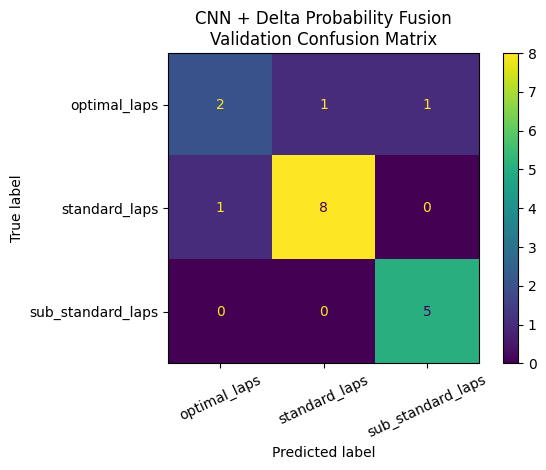

In [24]:
print(
    classification_report(
        fusion_true_labels,
        best_fusion_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    fusion_true_labels,
    best_fusion_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "CNN + Delta Probability Fusion\n"
    "Validation Confusion Matrix"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [25]:
mean_softmax_predictions = (
    fusion_validation_df[
        "mean_softmax_prediction"
    ].to_numpy()
)

majority_vote_predictions = (
    fusion_validation_df[
        "majority_vote_prediction"
    ].to_numpy()
)

fusion_comparison_df = pd.DataFrame({
    "model": [
        "Majority baseline",
        "CNN mean-softmax",
        "CNN majority vote",
        "Delta logistic regression",
        "CNN + delta fusion",
    ],

    "accuracy": [
        majority_validation_accuracy,

        accuracy_score(
            fusion_true_labels,
            mean_softmax_predictions,
        ),

        accuracy_score(
            fusion_true_labels,
            majority_vote_predictions,
        ),

        delta_validation_accuracy,

        accuracy_score(
            fusion_true_labels,
            best_fusion_predictions,
        ),
    ],

    "balanced_accuracy": [
        majority_validation_balanced_accuracy,

        balanced_accuracy_score(
            fusion_true_labels,
            mean_softmax_predictions,
        ),

        balanced_accuracy_score(
            fusion_true_labels,
            majority_vote_predictions,
        ),

        delta_validation_balanced_accuracy,

        balanced_accuracy_score(
            fusion_true_labels,
            best_fusion_predictions,
        ),
    ],
})

display(
    fusion_comparison_df
)


,model,accuracy,balanced_accuracy
0,Majority baseline,0.500000,0.333333
1,CNN mean-softmax,0.500000,0.333333
2,CNN majority vote,0.555556,0.416667
3,Delta logistic regression,0.833333,0.796296
4,CNN + delta fusion,0.833333,0.796296


In [ ]:
fusion_validation_results = (
    fusion_validation_df[[
        "global_lap_num",
        "session",
        "session_lap_num",
        "class_name",
        "class_index",
    ]]
    .copy()
)

fusion_validation_results[
    "fusion_predicted_class_index"
] = best_fusion_predictions

fusion_validation_results[
    "fusion_probability_optimal"
] = best_fusion_probabilities[:, 0]

fusion_validation_results[
    "fusion_probability_standard"
] = best_fusion_probabilities[:, 1]

fusion_validation_results[
    "fusion_probability_sub_standard"
] = best_fusion_probabilities[:, 2]

fusion_validation_results[
    "cnn_weight"
] = best_cnn_weight

fusion_validation_results[
    "delta_weight"
] = best_delta_weight

fusion_results_path = (
    manifest_dir
    / "fusion-validation-results.csv"
)

fusion_validation_results.to_csv(
    fusion_results_path,
    index=False,
)

print(
    "Saved fusion validation results:",
    fusion_results_path,
)


## 9. Current data notes

- The fixed split is session-based.
- Train: 85 laps / 340 images.
- Validation: 18 laps / 72 images.
- Test: 19 laps / 76 images.
- Delta data are available for 94 of the 122 eligible laps.
- The test set is intentionally not evaluated during development.
- Set `TRAIN_CNN = True` only when deliberately retraining the CNN.


# Refined model direction

The final classifier could receive:

- 3 mean brake CNN probabilities
- 3 mean throttle CNN probabilities
- delta_1
- delta_2
- delta_gap
- delta_count
- delta_missing

Conceptually:
```
Brake images ── CNN ── brake probabilities ─┐
                                            │
Throttle images ─ CNN ─ throttle probs ─────┼─ Logistic regression ─ final class
                                            │
Brake/throttle deltas ─ telemetry features ─┘
```
Order of changes:

- Evaluate a delta-only logistic regression.
- Aggregate CNN predictions to lap level.
- Tune weighted probability fusion.
- Then train a logistic stacking model using out-of-fold CNN probabilities.

Only after those experiments should we consider changing ResNet18 or building a custom architecture.

The most promising first version is therefore not a larger neural network. It is a session-split lap-level ensemble consisting of ResNet18 plus logistic regression on delta_1 and delta_2.

## Doubts

- I think we have to ensure that the laps without the delta data must be used in training the CNN. 

## A Some clarifications to remember:

### A.1 Image Use Guide
608 total references
- 103 incident images
- 13 images from irregular 2+2 input laps
- 4 images from the lap exceeding 30 seconds

= 488 CNN images

### A.2 Session vs Lap Split 
Keep the current session split as your main evaluation because it is the more defensible generalisation test.

Later, we can also run a secondary lap-grouped experiment using the same model. Comparing them would be informative:

Lap-grouped performance
versus
Session-grouped performance

A large performance drop under session grouping would indicate that session-specific conditions matter substantially. That itself would be a valuable result rather than evidence that the session split was wrong.

vs 

So in order to maintain similar conditions, i made changes to the game settings so that the weather was always the same, same camera position, same setup, no ui, same track conditions, no damage and that includes tye deg., and had these setting in every session. Also the graphics settings were the same too.

The only difference across sessions was my skill which i think you can see from this plot from my analysis notebook.

**Should try lap split later and LOOCV with it too.**

### A.3 Sessions are not of the same size
This might harm the training of the model and its performance

## TODO (might be outdated)
- Create a bespoke CNN model for this data set
- Think about cropping the image to only include the road maybe but I guess the image has to be square
- Think of how much padding should be applied to this CNN based on how important the borders of the image are, consult this article (https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175) and think about the stride too.
- Will probably need to add padding 
- Choose a method to normalize the data you have which is helpful for YOUR data


# Issue
SESSION 20 onwards, the sponsors on the wall are from qatar airways not louis vuitton, so there is a stark difference in colour but that is the extent of the difference.